# 🌱 HyWAP — Hyperspectral Water-stress Assessment at Parcel-level
### 🛰️ Arab Youth Space Hackathon 2026 · Challenge 813

**HyWAP turns a hyperspectral image into a per-parcel map of crop water stress — field by field, graded by severity.** 💧

This notebook runs the full analysis starting from the **lightweight study-area clips** produced by `HyWAP_preprocessing.ipynb` (a clipped ENVI cube + its 5 m panchromatic band), so the full scene is never loaded here. 🪶

**🧭 Pipeline**
1. 📊 Spectral **indices** + 🔬 **hyperspectral-only products**
2. 🛰️ **Pan-sharpening** (5 m) — used only for delineation
3. 🧩 **Field delineation** — AgriBound ➕ segmentation merge ➕ Douglas-Peucker
4. 💧 Per-parcel **water-stress severity** (relative %)
5. 🔁 **Cross-sensor validation** against Sentinel-2
6. 📈 **Season time series** + early-stress red-edge signal
7. 🗺️ **Interactive map** & GeoPackage exports

> ℹ️ **Scope.** This is a **description of state, not a forecast**, and severity is **relative to the scene**. We develop on **PRISMA** (239 bands, **400–2500 nm**, **30 m** + 5 m PAN) as the **open analogue of satellite 813**.

## 0. Install

In [1]:
# !pip -q install rasterio geopandas rasterstats scikit-image shapely matplotlib pandas numpy scipy folium
# !pip -q install pystac-client planetary-computer odc-stac rioxarray agribound ipywidgets
from IPython.display import clear_output, display; clear_output(); print("Dependencies installed.")

Dependencies installed.


### ☁️ 1a. Google Drive (Colab only)

The cell below mounts **Google Drive** and is only needed on **Google Colab** — it lets the notebook read the clips and write outputs to your Drive. On a **local machine it does nothing**: just leave it (it prints *"Not on Colab"* and moves on) and set **local paths** in the Configuration section below. 📁

> 💻 **Recommended: run locally.** The **AgriBound** step runs a deep-learning model (Delineate-Anything / YOLO) that is **compute-heavy** — it needs a fairly **robust machine** (ideally a GPU, or a good multi-core CPU + enough RAM). On the free Colab tier it can be slow or run out of memory, and the kernel sometimes needs a restart. For a smooth run, a **local workstation** (or a GPU Colab runtime) is the better choice. ⚙️

In [ ]:
try:
    from google.colab import drive; drive.mount("/content/drive")
except Exception: print("Not on Colab — use local paths in the config.")

## 1. Configuration

In [1]:
import re, os, warnings
import numpy as np, pandas as pd, geopandas as gpd
import rasterio
from rasterio.plot import show as rshow
from rasterio.features import geometry_mask, shapes
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import array_bounds
from rasterstats import zonal_stats
import matplotlib.pyplot as plt, matplotlib.dates as mdates, matplotlib.patches as mpatches
plt.rcParams.update({"figure.dpi":110,"font.size":10}); warnings.filterwarnings("ignore")

# === CLIPS from the preprocessing notebook ===
#WORKDIR   = "/content/drive/MyDrive/HyWap"
CLIP_CUBE = "D:\work\Hackathon\Inputs\Prisma_LGHARB_test"    # clipped ENVI cube (.hdr next to it)
CLIP_PAN  = "D:\work\Hackathon\Inputs\PRISMA_Pan_test.tif"   # clipped panchromatic

PRISMA_DATE = "2021-03-24"
TS_START, TS_END = "2020-11-01", "2021-06-30"

# --- cross-sensor validation (large AND healthy parcels) ---
VAL_WINDOW_DAYS = 5      # pick the Sentinel-2 scene closest to the PRISMA date
VAL_MIN_HA      = 3.0      # >3 ha so a parcel holds enough 30 m PRISMA pixels
VAL_NDVI_MIN    = 0.40     # "healthy" parcels only for the correlation

REFL_SCALE = 65535.0
SEG_SCALE, SEG_SIGMA, MIN_HA = 120, 0.8, 0.3
NDVI_MIN    = 0.30
SIMPLIFY_M  = 5
T = dict(RED=670, RE720=720, NIR790=790, NIR800=800, NIR860=860,
         GREEN=560, BLUE=490, SWIR1240=1240, SWIR1650=1650)
SEV_COLORS={"Healthy":"#1a9850","Mild":"#fee08b","Moderate":"#fc8d59","Severe":"#d73027","Non-vegetated":"#9e9e9e"}
SEV_ORDER=["Healthy","Mild","Moderate","Severe","Non-vegetated"]
print("Config loaded.")

Config loaded.


## 2. Load the study-area clip

Reads the clipped cube + panchromatic directly (they are already the study area). The AOI used downstream (Sentinel-2 bbox, AgriBound, exports) is the footprint of the clip.

In [2]:
def read_wl(hdr):
    txt=open(hdr,errors="ignore").read()
    m=re.search(r"wavelength\s*=\s*\{([^}]*)\}",txt,re.I|re.S)
    wl=np.array([float(x) for x in m.group(1).replace("\n"," ").split(",") if x.strip()])
    return wl*1000.0 if np.nanmax(wl)<100 else wl

src0=rasterio.open(CLIP_CUBE)
cube=src0.read().astype("float32"); cube_tr=src0.transform; cube_crs=src0.crs
if np.nanmax(cube)>1.5: cube/=REFL_SCALE
ndv=src0.nodata
if ndv is not None: cube[cube==ndv]=np.nan
psrc=rasterio.open(CLIP_PAN)
pan=psrc.read(1).astype("float32"); pan_tr=psrc.transform; pan_crs=psrc.crs
pan[pan<=0]=np.nan

wl=read_wl(CLIP_CUBE+".hdr")
def band(t): return cube[int(np.argmin(np.abs(wl-t)))]
valid=np.isfinite(band(T["NIR860"])) & (band(T["NIR860"])>0)

from shapely.geometry import box
l,b,r,t=array_bounds(cube.shape[1],cube.shape[2],cube_tr)
aoi=gpd.GeoDataFrame({"geometry":[box(l,b,r,t)]},crs=cube_crs); aoi_c=aoi
print(f"Clip loaded — cube {cube.shape} | PAN {pan.shape} | {wl.min():.0f}-{wl.max():.0f} nm")

Clip loaded — cube (230, 118, 165) | PAN (708, 985) | 407-2497 nm


**Check — the clipped study area (cube RGB + panchromatic).**

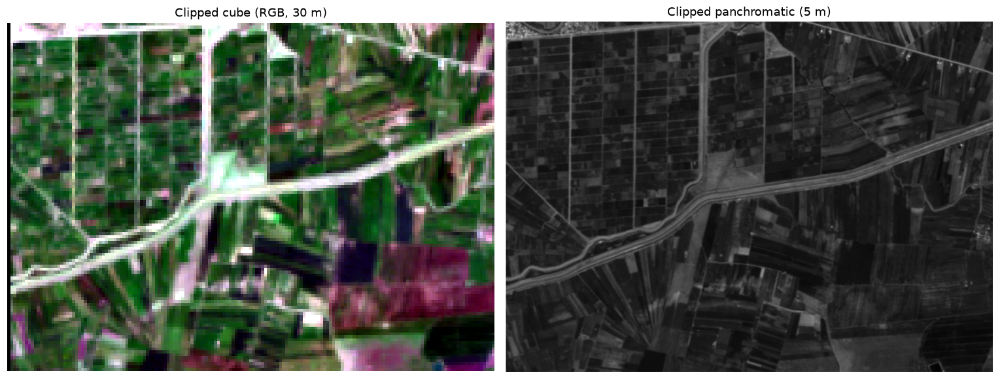

In [3]:
def q(a):
    lo,hi=np.nanpercentile(a,(2,98)); return np.clip((a-lo)/(hi-lo),0,1)
fig,ax=plt.subplots(1,2,figsize=(14,6))
ax[0].imshow(np.dstack([q(band(T["RED"])),q(band(T["GREEN"])),q(band(T["BLUE"]))])); ax[0].set_title("Clipped cube (RGB, 30 m)"); ax[0].axis("off")
ax[1].imshow(pan,cmap="gray"); ax[1].set_title("Clipped panchromatic (5 m)"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 3. Water-stress indices (the ones that inform on stress)

Indices grouped by what they inform on — 🟢 greenness (NDVI, SAVI), 🍂 pigment / red-edge (NDRE, REP), 💧 leaf-water (NDWI-Gao, NDII, MSI), and, when the cube reaches the SWIR-2 region, 🌾 dry-matter / residue (NDNI, NDTI). Each map carries its own colour bar for easy reading.

SWIR-2 indices added: NDNI, NDTI


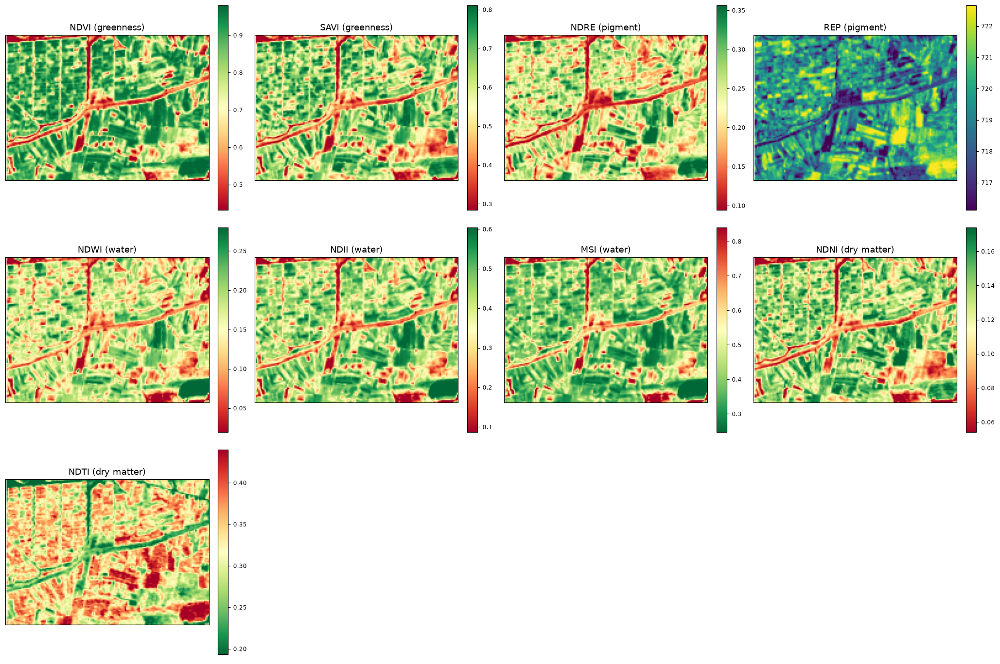

In [4]:
def nd(a,b):
    with np.errstate(divide="ignore",invalid="ignore"): o=(a-b)/(a+b)
    o[~valid]=np.nan; return o
R=band(T["RED"]); N800=band(T["NIR800"]); N790=band(T["NIR790"]); N860=band(T["NIR860"])
RE720=band(T["RE720"]); W1240=band(T["SWIR1240"]); S1650=band(T["SWIR1650"])

# --- greenness ---
NDVI=nd(N800,R)
L=0.5
with np.errstate(divide="ignore",invalid="ignore"): SAVI=((N800-R)/(N800+R+L))*(1+L)
SAVI[~valid]=np.nan
# --- pigment / red-edge ---
NDRE=nd(N790,RE720)
R670=band(670); R700=band(700); R740=band(740); R780=band(780)
with np.errstate(divide="ignore",invalid="ignore"):
    REP=700.0+40.0*(((R670+R780)/2.0 - R700)/(R740-R700))     # red-edge position (Guyot-Baret)
REP[~valid]=np.nan
# --- leaf water ---
NDWI=nd(N860,W1240); NDII=nd(N860,S1650)
with np.errstate(divide="ignore",invalid="ignore"): MSI=S1650/N860
MSI[~valid]=np.nan

indices={"NDVI":NDVI,"SAVI":SAVI,"NDRE":NDRE,"REP":REP,"NDWI":NDWI,"NDII":NDII,"MSI":MSI}
FAMILY={"NDVI":"greenness","SAVI":"greenness","NDRE":"pigment","REP":"pigment",
        "NDWI":"water","NDII":"water","MSI":"water","NDNI":"dry matter","NDTI":"dry matter"}
CMAP={"MSI":"RdYlGn_r","NDTI":"RdYlGn_r","REP":"viridis"}   # reversed where higher = drier

# --- SWIR-2 indices (added when the cube reaches the SWIR-2 region, > ~2150 nm) ---
if np.nanmax(wl) >= 2150:
    S1510=band(1510); S1680=band(1680); S2200=band(2200)
    with np.errstate(divide="ignore",invalid="ignore"):
        a1=np.log(1.0/np.clip(S1510,1e-6,None)); a2=np.log(1.0/np.clip(S1680,1e-6,None))
        NDNI=(a1-a2)/(a1+a2)                 # canopy nitrogen / dry matter (Serrano log form)
    NDNI[~valid]=np.nan
    NDTI=nd(S1650,S2200)                     # residue / tillage: SWIR1 vs SWIR2
    indices["NDNI"]=NDNI; indices["NDTI"]=NDTI
    print("SWIR-2 indices added: NDNI, NDTI")
else:
    print("Cube does not reach SWIR-2 (> 2150 nm) -> NDNI/NDTI skipped.")

# --- display: one colour bar per map, title shows the family ---
h,w=cube.shape[1],cube.shape[2]; l,b,rr,t=array_bounds(h,w,cube_tr); ext=(l,rr,b,t)
n=len(indices); ncol=4; nrow=int(np.ceil(n/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(4.7*ncol,4.2*nrow)); axes=np.atleast_1d(axes).ravel()
for ax,(nm,a) in zip(axes,indices.items()):
    lo,hi=np.nanpercentile(a,(2,98))
    im=ax.imshow(a,cmap=CMAP.get(nm,"RdYlGn"),extent=ext,vmin=lo,vmax=hi)
    ax.set_title(f"{nm} ({FAMILY.get(nm,'')})"); ax.set_xticks([]); ax.set_yticks([])
    cb=fig.colorbar(im,ax=ax,fraction=.046,pad=.04); cb.ax.tick_params(labelsize=8)
for ax in axes[n:]: ax.axis("off")
plt.tight_layout(); plt.savefig("indices.png",dpi=130,bbox_inches="tight"); plt.show()

## 🔬 3b. Hyperspectral-specific products — what Sentinel-2 cannot do

The indices above are broadband-equivalent (Sentinel-2 can compute them too). These use the **narrow, contiguous hyperspectral bands** and are the genuine hyperspectral contribution 🧬:

- **PRI** (531 / 570 nm) — xanthophyll / photosynthetic down-regulation; reacts to stress **before** NDVI drops. ⏱️
- **WBI** (R900 / R970) — water band index.
- **CRD970 / CRD1200** — **continuum-removal absorption depth** at the 970 nm and 1200 nm water features: a direct, physical proxy of **canopy water content** (deeper = more water). 💧
- **REIP** — red-edge inflection point from the **1st derivative** over 680–750 nm (precise chlorophyll / stress tracking).

They are added to `indices`, so they also get per-parcel statistics and are exported. 📤

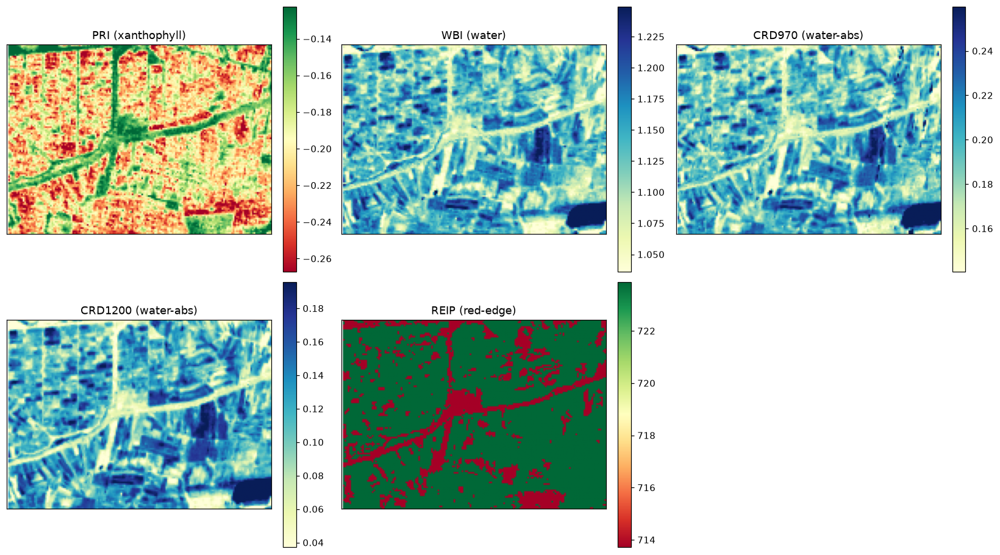

Hyperspectral products added: ['PRI', 'WBI', 'CRD970', 'CRD1200', 'REIP']


In [5]:
# ---- hyperspectral-only products (need contiguous narrow bands) ----
def bidx(t): return int(np.argmin(np.abs(wl-t)))

# PRI - photochemical reflectance index (early stress)
PRI=nd(band(531),band(570))

# WBI - water band index R900/R970 (higher = wetter)
with np.errstate(divide="ignore",invalid="ignore"): WBI=band(900)/band(970)
WBI[~valid]=np.nan

# continuum-removal absorption DEPTH at the 970 nm and 1200 nm water features
def cont_depth(wl_left, wl_right, wlo, whi):
    il,ir=bidx(wl_left),bidx(wl_right); i0,i1=sorted([bidx(wlo),bidx(whi)])
    Rl,Rr=cube[il],cube[ir]; best=np.zeros_like(Rl,dtype="float32")
    for i in range(i0,i1+1):
        frac=(wl[i]-wl[il])/(wl[ir]-wl[il]+1e-9); cont=Rl+frac*(Rr-Rl)
        with np.errstate(divide="ignore",invalid="ignore"):
            best=np.maximum(best, 1.0-cube[i]/(cont+1e-9))
    best[~valid]=np.nan; return best
CRD970 =cont_depth(900,1080,930,1010)      # deeper = more canopy water
CRD1200=cont_depth(1080,1320,1150,1260)

# REIP - red-edge inflection point via 1st derivative over 680-750 nm
reidx=np.where((wl>=680)&(wl<=750))[0]
if len(reidx)>=3:
    dR=np.gradient(cube[reidx], wl[reidx], axis=0)
    REIP=wl[reidx][np.argmax(dR,axis=0)].astype("float32"); REIP[~valid]=np.nan
else:
    REIP=np.full(valid.shape,np.nan,dtype="float32")

HSI_PRODUCTS={"PRI":PRI,"WBI":WBI,"CRD970":CRD970,"CRD1200":CRD1200,"REIP":REIP}
indices.update(HSI_PRODUCTS)
FAMILY.update({"PRI":"xanthophyll","WBI":"water","CRD970":"water-abs","CRD1200":"water-abs","REIP":"red-edge"})
CMAP.update({"PRI":"RdYlGn","WBI":"YlGnBu","CRD970":"YlGnBu","CRD1200":"YlGnBu","REIP":"RdYlGn"})

# display
h,w=cube.shape[1],cube.shape[2]; l,b,rr,t=array_bounds(h,w,cube_tr); ext=(l,rr,b,t)
items=list(HSI_PRODUCTS.items()); ncol=3; nrow=int(np.ceil(len(items)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(5*ncol,4.2*nrow)); axes=np.atleast_1d(axes).ravel()
for ax,(nm,a) in zip(axes,items):
    lo,hi=np.nanpercentile(a,(2,98))
    im=ax.imshow(a,cmap=CMAP.get(nm,"viridis"),extent=ext,vmin=lo,vmax=hi)
    ax.set_title(f"{nm} ({FAMILY.get(nm,'')})"); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im,ax=ax,fraction=.046,pad=.04)
for ax in axes[len(items):]: ax.axis("off")
plt.tight_layout(); plt.savefig("hsi_products.png",dpi=130,bbox_inches="tight"); plt.show()
print("Hyperspectral products added:", list(HSI_PRODUCTS))

### 🧭 Interpreting the hyperspectral products

- **PRI** — around **0** in healthy canopies; **more negative** = xanthophyll cycle engaged = early photosynthetic / water stress, **before** NDVI drops.
- **WBI (R900/R970)** — **higher = more leaf water**; values dropping toward ~1 indicate drying.
- **CRD970 / CRD1200** (continuum-removal depth) — **deeper (larger) = more canopy water**; a shallow 970 / 1200 nm feature = water-depleted canopy. CRD970 is the most robust of the two.
- **REIP** — healthy, chlorophyll-rich canopies sit at a **longer** red-edge position (~720–730 nm); a **shift to shorter** wavelengths flags stress / senescence.

👉 Read them together: a parcel that is still green (high NDVI) but shows **low PRI + shallow CRD970** is an **early-stress** candidate the broadband indices would miss.

## 4. Pan-sharpening — fully in Python (Brovey)

A 4-band composite (R, G, B, NIR) built from the cube is sharpened with the 5 m panchromatic band. ⚠️ Used only for delineation — indices stay on the native hyperspectral resolution.

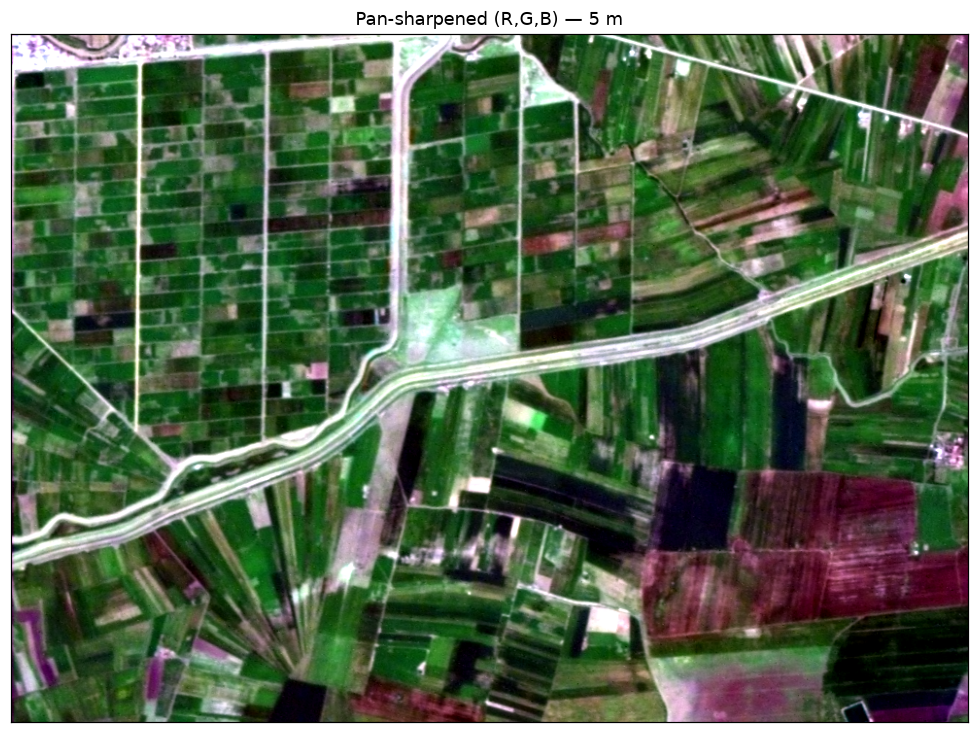

In [6]:
# 4-band low-res composite (by wavelength)
ms = np.stack([band(T["RED"]),band(T["GREEN"]),band(T["BLUE"]),band(T["NIR860"])]).astype("float32")

# resample MS onto the PAN grid, then Brovey sharpen
H,Wd = pan.shape
ms_hr = np.empty((4,H,Wd),"float32")
for i in range(4):
    reproject(ms[i], ms_hr[i], src_transform=cube_tr, src_crs=cube_crs,
              dst_transform=pan_tr, dst_crs=pan_crs, resampling=Resampling.bilinear)
# inten = np.nanmean(ms_hr,axis=0)+1e-6
# pan_sharp = ms_hr*(pan/inten)                      # (4, H, W) at 5 m
# resample MS onto the PAN grid (inchangé)
H, Wd = pan.shape
ms_hr = np.empty((4, H, Wd), "float32")
for i in range(4):
    reproject(ms[i], ms_hr[i], src_transform=cube_tr, src_crs=cube_crs,
              dst_transform=pan_tr, dst_crs=pan_crs, resampling=Resampling.bilinear)

# Gram-Schmidt : intensité = bandes couvertes par la PAN seulement (R, G, B)
valid = np.isfinite(pan) & np.all(np.isfinite(ms_hr), axis=0)
I = ms_hr[:3].mean(axis=0)

# PAN ramenée à la moyenne / écart-type de I (sinon on injecte un biais radiométrique)
p, i_ = pan[valid], I[valid]
pan_m = (pan - p.mean()) / p.std() * i_.std() + i_.mean()
D = pan_m - I                                   # le détail spatial à injecter

# gain par bande = cov(bande, I) / var(I)  -> le PIR reçoit moins de détail que le visible
gains = np.array([np.cov(ms_hr[k][valid], i_)[0, 1] / i_.var() for k in range(4)], "float32")
pan_sharp = ms_hr + gains[:, None, None] * D
pan_sharp[:, ~valid] = np.nan

# save + display (stretched RGB)
prof={"driver":"GTiff","height":H,"width":Wd,"count":4,"dtype":"float32",
      "crs":pan_crs,"transform":pan_tr,"nodata":np.nan}
with rasterio.open("PRISMA_pansharp.tif","w",**prof) as d: d.write(pan_sharp.astype("float32"))
def stretch(a):
    lo,hi=np.nanpercentile(a,(2,98)); return np.clip((a-lo)/(hi-lo),0,1)
rgb=np.stack([stretch(pan_sharp[0]),stretch(pan_sharp[1]),stretch(pan_sharp[2])],-1)
fig,ax=plt.subplots(figsize=(9,7)); rshow(np.transpose((rgb*255).astype("uint8"),(2,0,1)),transform=pan_tr,ax=ax)
ax.set_title("Pan-sharpened (R,G,B) — 5 m"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig("pansharp.png",dpi=130,bbox_inches="tight"); plt.show()

**Download the pan-sharpened result to inspect it (e.g. in QGIS).**

In [10]:
try:
    from google.colab import files; files.download("PRISMA_pansharp.tif")
except Exception:
    print("Not on Colab — the file PRISMA_pansharp.tif is saved in the working directory.")

Not on Colab — the file PRISMA_pansharp.tif is saved in the working directory.


## 5. Field delineation — segmentation + AgriBound (computed here) + Douglas-Peucker

Our delineation combines two complementary views and keeps the best of each 🤝:

1. 🤖 **AgriBound** (Delineate-Anything / YOLO) on the pan-sharpened image → clean field outlines, and it naturally **ignores roads / non-field**.
2. 🧩 **Felzenszwalb segmentation** of the same image → internal detail where fields touch.
3. ✂️ **Intersection (merge)** of the two → AgriBound's clean borders *with* the segmentation's internal splits, roads dropped.
4. 📐 **Douglas-Peucker** boundary simplification → lighter, smoother polygons.

The delineation and the study-area boundary are exported as **GeoPackages**. 🗂️

> 🤖 **Heads-up on AgriBound.** The first run downloads the Delineate-Anything (YOLO) weights and loads PyTorch. On some kernels the runtime **needs a restart** before AgriBound runs cleanly — if you hit a torch / CUDA / import error, just **Restart the kernel and re-run from section 1**. ⏳ Inference also runs tile-by-tile, so give it a minute — a little patience pays off.

In [11]:
import rasterio
import geopandas as gpd
from shapely.geometry import box

SRC = "PRISMA_pansharp.tif"
AOI = "study_area.geojson"

with rasterio.open(SRC) as ds:
    bounds = ds.bounds
    crs = ds.crs
    px_x = abs(ds.res[0])
    px_y = abs(ds.res[1])

if crs is None:
    raise ValueError("L'image ne possède pas de système de coordonnées.")

# Rectangle avec une marge intérieure de 2 pixels sur chaque bord
geometry = box(
    bounds.left, bounds.bottom,
    bounds.right, bounds.top
)


gpd.GeoDataFrame(
    {"id": [1]},
    geometry=[geometry],
    crs=crs,
).to_crs(epsg=4326).to_file(AOI, driver="GeoJSON")

print("GeoJSON créé :", AOI)

GeoJSON créé : study_area.geojson


### 🤖 5a. Run AgriBound — read this before you execute

> ⏳ **This is the heavy step — no panic if the cell turns red!** 🔴
>
> AgriBound loads a deep-learning model (Delineate-Anything / YOLO) on top of PyTorch, and on most setups the kernel needs a little warm-up dance the first time:
>
> 1. ▶️ **Run this cell.** The first run often throws an error (torch / import). That's expected — breathe. 😌
> 2. 🔄 **Restart the kernel**, then **run this cell again.**
> 3. 💥 If the kernel *dies* afterwards, **restart once more**, run everything **from the top**, and this time **skip this AgriBound cell** → go straight to the next one, which **loads the saved result** (`fields_prisma.gpkg`).
>
> ✅ **For a smooth, reproducible run:** compute AgriBound **once** to create `fields_prisma.gpkg`, then on every later run just **load that file** and continue — no need to recompute. The delineation is exactly the same.
>
> ⏱️ On CPU, inference runs tile-by-tile, so give it a minute. A red cell here is normal — the **saved GeoPackage** is what matters. 🙂

In [1]:
import logging
from pathlib import Path
import agribound

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(message)s", datefmt="%H:%M:%S")

OUT = Path("fields_prisma.gpkg")
OUT.parent.mkdir(parents=True, exist_ok=True)
if OUT.exists():
    OUT.unlink()   # sinon agribound recharge l'ancien résultat sans rien recalculer

gdf = agribound.delineate(
    study_area="study_area.geojson",
    source="local",
    engine="delineate-anything",
    local_tif_path="PRISMA_pansharp.tif",
    output_path=str(OUT),
    bands={"R": 1, "G": 2, "B": 3},
    lulc_filter=False,
    min_field_area_m2=2000,        # 0,2 ha (80 px à 5 m) au lieu de 2 ha
    simplify_tolerance=1.0,
    device="auto",
    n_workers=1,
    engine_params={"super_resolution": 4},   # pas de "confidence" : défaut 0,15
)

print(f"\n{len(gdf)} parcelles détectées")
if len(gdf) and "metrics:area" in gdf.columns:
    a = gdf["metrics:area"]
    print(f"surface totale {a.sum()/1e4:,.0f} ha | médiane {a.median()/1e4:.2f} ha")

13:00:51 Agribound pipeline: source=local, engine=delineate-anything, year=2024
13:00:51 Step 1: Building composite
13:00:51 Using local GeoTIFF: PRISMA_pansharp.tif
13:00:51 Composite ready: .agribound_cache\local_clipped_PRISMA_pansharp.tif
13:00:51 Step 3: Running delineation engine (delineate-anything)
13:00:51 Loading Delineate-Anything model (large)
13:00:52 HTTP Request: HEAD https://huggingface.co/MykolaL/DelineateAnything/resolve/main/DelineateAnything.pt "HTTP/1.1 302 Found"
13:00:52 Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
13:00:58 Running Delineate-Anything inference on .agribound_cache\local_clipped_PRISMA_pansharp.tif
13:00:58 Delineate-Anything repo not found, using direct YOLO inference
C:\Users\myhua\miniforge_envs\Hywap\Lib\site-packages\agribound\engines\delineate_anything.py:484: RuntimeWarning: invalid value encountered in cast
  full_image[b] = band.astype(np.uint8)
13


7 parcelles détectées
surface totale 1,622 ha | médiane 51.02 ha


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.028096844..0.33709598].


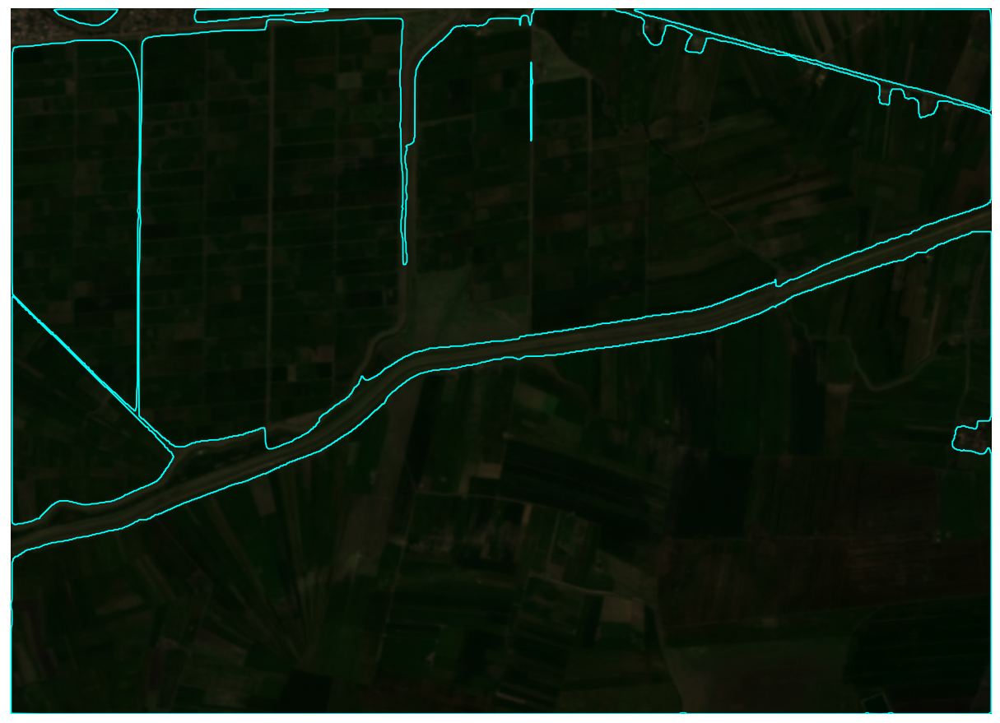

In [7]:
import geopandas as gpd, rasterio, matplotlib.pyplot as plt
from rasterio.plot import show

gdf = gpd.read_file("fields_prisma.gpkg")
fig, ax = plt.subplots(figsize=(14, 14))
with rasterio.open("PRISMA_pansharp.tif") as ds:
    show(ds.read([1, 2, 3]), transform=ds.transform, ax=ax)
gdf.to_crs(ds.crs).boundary.plot(ax=ax, color="cyan", linewidth=1.2)
ax.set_axis_off()
plt.savefig("resultat.png", dpi=200, bbox_inches="tight")

Raw segments: 1068


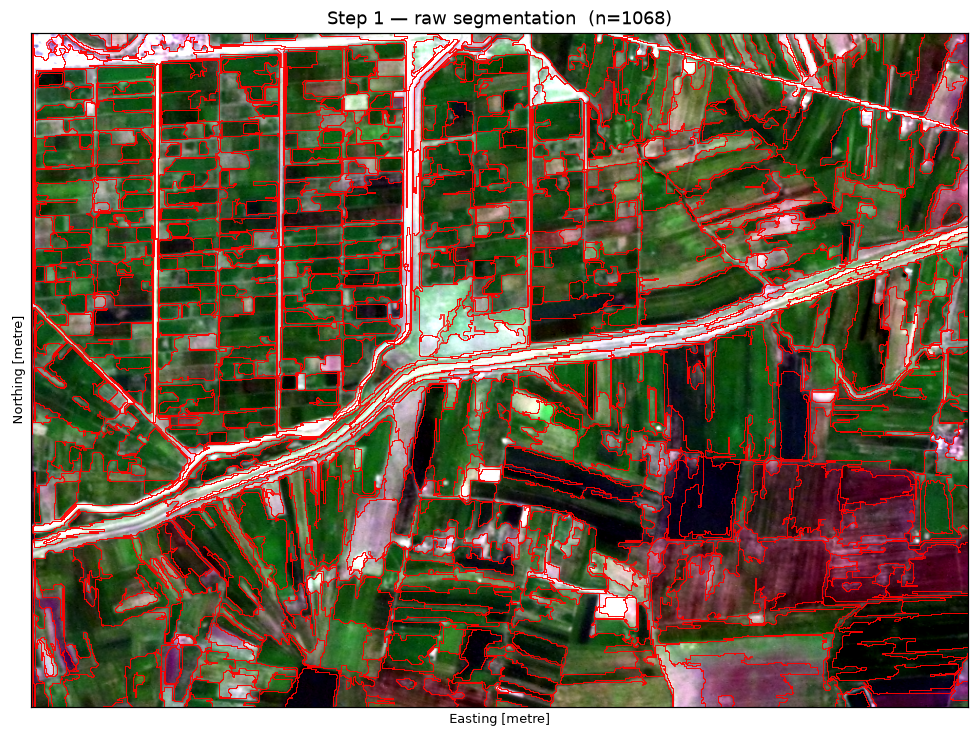

In [9]:
from skimage.segmentation import felzenszwalb
from skimage.exposure import rescale_intensity
from shapely.geometry import shape
px_area=abs(pan_tr.a*pan_tr.e)
rgb01=np.stack([rescale_intensity(pan_sharp[i],in_range=tuple(np.nanpercentile(pan_sharp[i],(2,98))),out_range=(0,1)) for i in range(4)],-1)
rgb01=np.nan_to_num(rgb01)
seg=felzenszwalb(rgb01,scale=SEG_SCALE,sigma=SEG_SIGMA,min_size=int(MIN_HA*10000/px_area))
polys=[shape(g) for g,v in shapes(seg.astype("int32"),transform=pan_tr) if shape(g).area>=MIN_HA*10000]
parcels=gpd.GeoDataFrame({"pid":range(len(polys))},geometry=polys,crs=pan_crs).to_crs(cube_crs)
parcels["area_ha"]=parcels.area/10000

# verification display used after every cleaning step
rgb_disp=np.transpose((rgb*255).astype("uint8"),(2,0,1))
def show_parcels(gdf,title):
    fig,ax=plt.subplots(figsize=(9,7)); rshow(rgb_disp,transform=pan_tr,ax=ax)
    gdf.to_crs(pan_crs).boundary.plot(ax=ax,edgecolor="red",linewidth=0.5)
    ax.set_title(f"{title}  (n={len(gdf)})"); ax.set_xticks([]); ax.set_yticks([]); plt.tight_layout(); plt.show()

print("Raw segments:",len(parcels))
show_parcels(parcels,"Step 1 — raw segmentation")

### 5b. AgriBound result
Reload the AgriBound field polygons saved in 5a (fields_prisma.gpkg) so they can be merged with the segmentation in 5c. Point AGRIBOUND_PATH at your own result if you computed it elsewhere (.gpkg / .shp).

AgriBound fields: 7


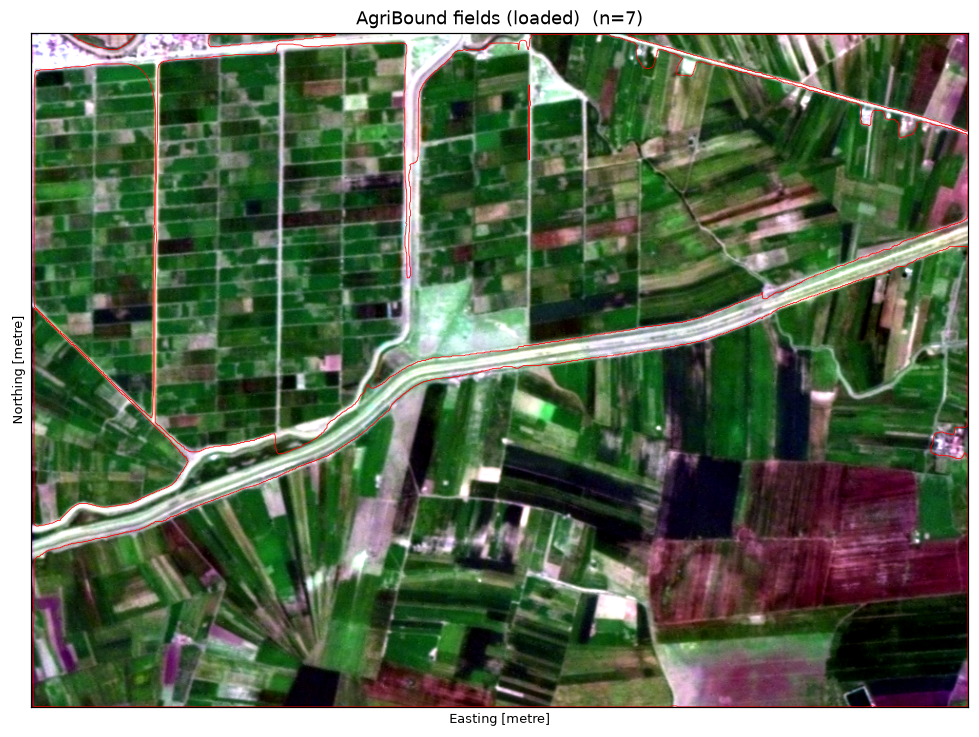

In [10]:
AGRIBOUND_PATH = "fields_prisma.gpkg"   # your AgriBound result
ab = gpd.read_file(AGRIBOUND_PATH).to_crs(cube_crs)
ab = ab[ab.geometry.notna() & ~ab.geometry.is_empty]
print("AgriBound fields:", len(ab))
show_parcels(ab, "AgriBound fields (loaded)")

### 5c. Merge with AgriBound + Douglas-Peucker + export GeoPackages

Merged with AgriBound -> 985 parcels
Final parcels: 985  (Douglas-Peucker tol = 5 m)


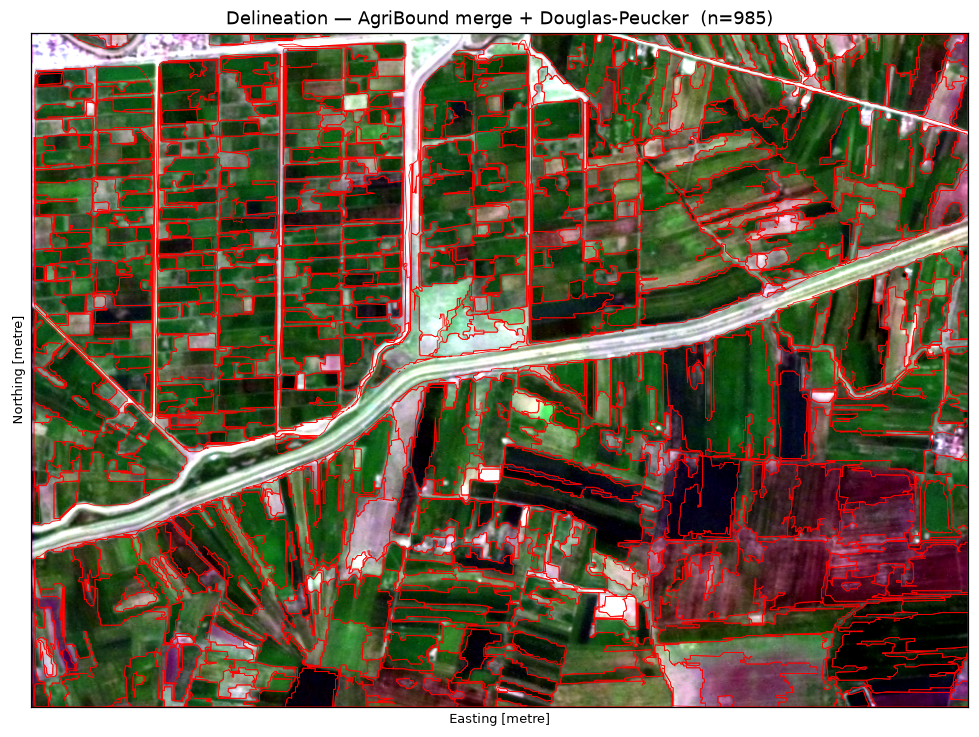

Saved: outputs/parcels_delineation.gpkg , outputs/study_area_boundary.gpkg


In [11]:
os.makedirs("outputs",exist_ok=True)
# merge AgriBound (ab, computed in 5b) with the segmentation
merged=gpd.overlay(ab[["geometry"]], parcels[["geometry"]], how="intersection")
merged=merged[merged.area>=MIN_HA*10000].reset_index(drop=True)
parcels=merged
print("Merged with AgriBound ->",len(parcels),"parcels")

# Douglas-Peucker boundary simplification (keeps the shape, drops redundant vertices)
if SIMPLIFY_M>0:
    parcels["geometry"]=parcels.geometry.simplify(SIMPLIFY_M, preserve_topology=True)
    parcels=parcels[~parcels.geometry.is_empty & parcels.geometry.notna()]
parcels=parcels.reset_index(drop=True)
parcels["pid"]=parcels.index.astype(int); parcels["area_ha"]=parcels.area/10000
print(f"Final parcels: {len(parcels)}  (Douglas-Peucker tol = {SIMPLIFY_M} m)")
show_parcels(parcels,"Delineation — AgriBound merge + Douglas-Peucker")

# --- save the delineation result and the study-area boundary as GeoPackages ---
parcels[["pid","area_ha","geometry"]].to_file("outputs/parcels_delineation.gpkg",driver="GPKG")
aoi.to_crs(cube_crs).to_file("outputs/study_area_boundary.gpkg",driver="GPKG")
print("Saved: outputs/parcels_delineation.gpkg , outputs/study_area_boundary.gpkg")

In [12]:
# download the delineation + study-area boundary GeoPackages (Colab)
try:
    from google.colab import files
    files.download("outputs/parcels_delineation.gpkg")
    files.download("outputs/study_area_boundary.gpkg")
except Exception:
    print("Not on Colab — files are in outputs/: parcels_delineation.gpkg , study_area_boundary.gpkg")

Not on Colab — files are in outputs/: parcels_delineation.gpkg , study_area_boundary.gpkg


> **Comparison reference:** Microsoft **Fields of The World** provides open field-boundary data — it can be added as a comparison layer to benchmark the delineation.

## 6. Per-parcel water-stress severity — composite index (relative %)

Rather than relying on a single index, each parcel gets a composite stress score 🎯. For every stress-related index (NDWI, NDII, NDRE, MSI, plus the hyperspectral PRI and water-absorption depth CRD970) we rank the parcel against all vegetated parcels, orient it so higher = more stress, and average these percentiles into one relative stress % (0–100).

A parcel at a high % is more stressed relative to the scene and should be prioritised. 🟩🟨🟧🟥 Classes (Healthy / Mild / Moderate / Severe) are cut from this %. Two maps follow: a continuous synthesis map (the % itself) and the class map.

Composite stress built from: ['NDWI', 'NDII', 'NDRE', 'MSI', 'PRI', 'CRD970']


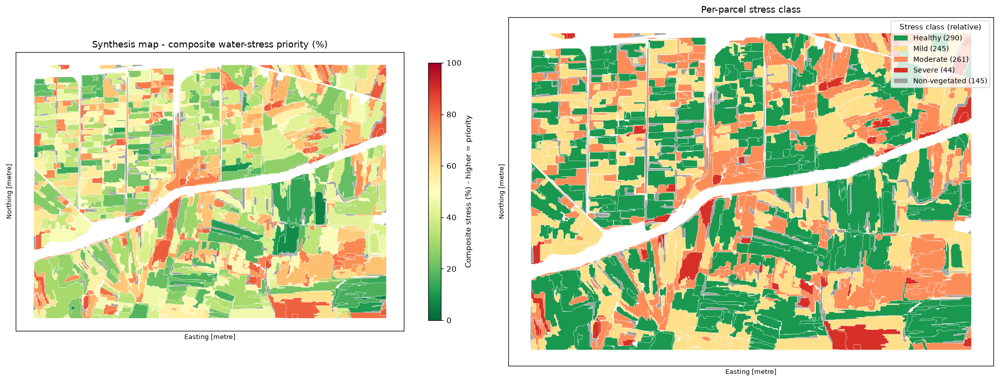

severity
Healthy          290
Mild             245
Moderate         261
Severe            44
Non-vegetated    145
Name: count, dtype: int64
\nTop-10 priority parcels (most stressed):
 pid  stress_pct severity  area_ha
 309        84.1   Severe 0.908750
 746        84.0   Severe 0.805000
 316        83.9   Severe 2.678123
 893        83.7   Severe 1.412500
 924        83.2   Severe 0.431250
 982        83.0   Severe 2.865000
 705        82.9   Severe 0.315000
 962        82.9   Severe 0.957162
 870        82.8   Severe 2.291250
 910        82.7   Severe 0.758165


In [13]:
# ---- per-parcel statistics (zonal means, inner buffer to avoid edge pixels) ----
stat_geom=[]
for g in parcels.geometry:
    b=g.buffer(-10); stat_geom.append(g if (b.is_empty or b is None) else b)
stat_geom=gpd.GeoSeries(stat_geom,crs=cube_crs)
def zmean(a): return [s["mean"] for s in zonal_stats(stat_geom,a,affine=cube_tr,stats="mean",nodata=np.nan)]
for n in indices: parcels[n]=zmean(indices[n])
veg=parcels["NDVI"]>=NDVI_MIN

# ---- composite stress index: synthesis of several indices, as a relative % ----
# orientation = how the index moves WITH stress: "low" (low value = stress) is inverted, "high" is kept.
STRESS_WEIGHTS = {"NDWI":"low","NDII":"low","NDRE":"low","MSI":"high","PRI":"low","CRD970":"low"}
comp=[]; used=[]
for nm,orient in STRESS_WEIGHTS.items():
    if nm in parcels.columns and parcels[nm].where(veg).notna().sum()>=3:
        rk=parcels[nm].where(veg).rank(pct=True)
        comp.append(rk if orient=="high" else 1-rk); used.append(nm)
parcels["stress_pct"]=(100*pd.concat(comp,axis=1).mean(axis=1)).round(1) if comp else np.nan   # 0-100, higher = more stress
parcels["priority"]=parcels["stress_pct"].rank(ascending=False, method="min")                   # 1 = most stressed

def cls(r):
    if (not veg.loc[r.name]) or pd.isna(r["stress_pct"]): return "Non-vegetated"
    s=r["stress_pct"]; return "Severe" if s>=80 else "Moderate" if s>=60 else "Mild" if s>=40 else "Healthy"
parcels["severity"]=parcels.apply(cls,axis=1)
parcels.to_file("HyWAP_severity.gpkg",driver="GPKG")
print("Composite stress built from:", used)

# ---- maps: (a) continuous synthesis %  (b) relative classes ----
fig,ax=plt.subplots(1,2,figsize=(18,8))
nonveg=parcels[parcels.severity=="Non-vegetated"]; vegp=parcels[parcels.severity!="Non-vegetated"]
if len(nonveg): nonveg.plot(ax=ax[0],facecolor="#9e9e9e",edgecolor="white",linewidth=0.2)
if len(vegp):
    vegp.plot(ax=ax[0],column="stress_pct",cmap="RdYlGn_r",vmin=0,vmax=100,edgecolor="white",linewidth=0.2,
              legend=True,legend_kwds={"label":"Composite stress (%) - higher = priority","shrink":0.6})
ax[0].set_title("Synthesis map - composite water-stress priority (%)"); ax[0].set_aspect("equal"); ax[0].set_xticks([]); ax[0].set_yticks([])
for sev in SEV_ORDER:
    sub=parcels[parcels.severity==sev]
    if len(sub): sub.plot(ax=ax[1],facecolor=SEV_COLORS[sev],edgecolor="white",linewidth=0.2)
ax[1].legend(handles=[mpatches.Patch(facecolor=SEV_COLORS[s],label=f"{s} ({int((parcels.severity==s).sum())})") for s in SEV_ORDER if (parcels.severity==s).any()],
             title="Stress class (relative)",loc="upper right",fontsize=9)
ax[1].set_title("Per-parcel stress class"); ax[1].set_aspect("equal"); ax[1].set_xticks([]); ax[1].set_yticks([])
plt.tight_layout(); plt.savefig("severity_map.png",dpi=130,bbox_inches="tight"); plt.show()
print(parcels["severity"].value_counts().reindex(SEV_ORDER).dropna())
print("\\nTop-10 priority parcels (most stressed):")
print(parcels.sort_values("priority")[["pid","stress_pct","severity","area_ha"]].head(10).to_string(index=False))

### Indices with parcel boundaries (verification)

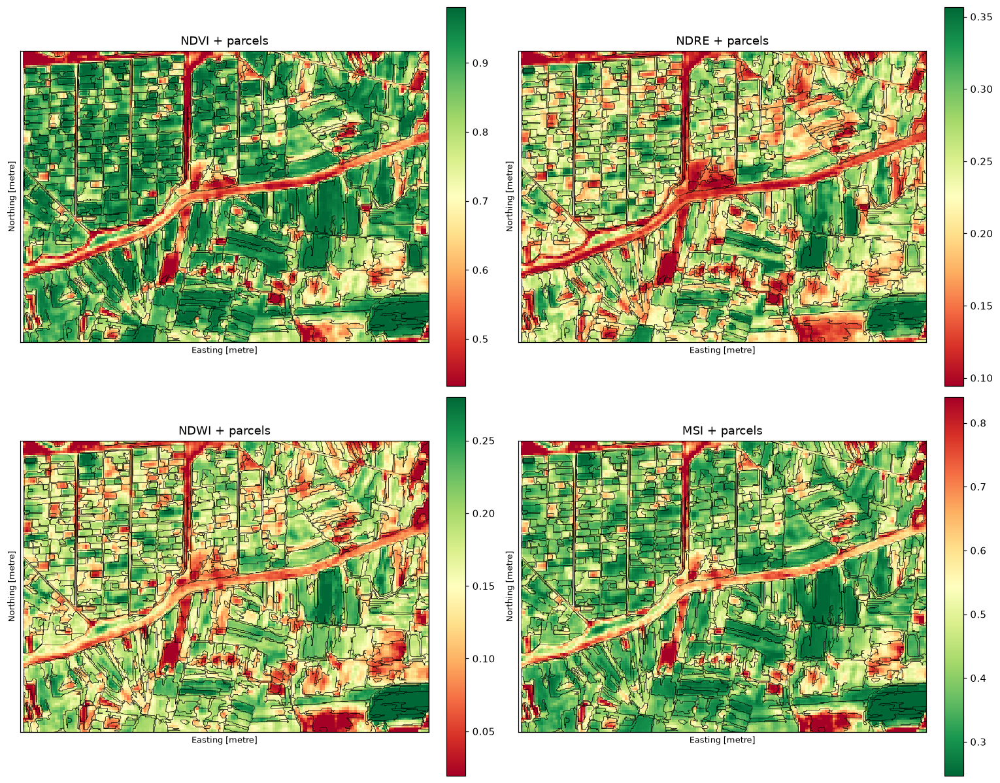

In [14]:
# final parcel boundaries overlaid on a few indices, each with its colour bar
ov=["NDVI","NDRE","NDWI","MSI"]
h,w=cube.shape[1],cube.shape[2]; l,b,rr,t=array_bounds(h,w,cube_tr); ext=(l,rr,b,t)
pb=parcels.to_crs(cube_crs).boundary
fig,axes=plt.subplots(2,2,figsize=(14,11)); axes=axes.ravel()
for ax,nm in zip(axes,ov):
    a=indices[nm]; lo,hi=np.nanpercentile(a,(2,98))
    im=ax.imshow(a,cmap=CMAP.get(nm,"RdYlGn"),extent=ext,vmin=lo,vmax=hi)
    pb.plot(ax=ax,edgecolor="black",linewidth=0.3)
    ax.set_title(f"{nm} + parcels"); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im,ax=ax,fraction=.046,pad=.04)
plt.tight_layout(); plt.savefig("indices_parcels.png",dpi=130,bbox_inches="tight"); plt.show()

## 7. Cross-sensor validation — Sentinel-2 downsampled to PRISMA (30 m), closest date, large parcels

We take the Sentinel-2 scene **closest in time** to the PRISMA date, **downsample Sentinel-2 to the PRISMA 30 m grid** (so both are at the same native resolution), and compare **per parcel on large parcels only** (≥ `VAL_MIN_HA` ha). Two checks — 🟢 **NDVI** and 💧 **leaf water** (PRISMA NDII vs S2 NDMI) — reported with **Pearson r**, **Spearman ρ** (relative ordering) and the 1:1 line.

In [22]:
val_ok=True
try:
    import planetary_computer as pc, pystac_client
    from odc.stac import load as odc_load
    import rioxarray  # noqa
    bbox=transform_bounds(cube_crs,"EPSG:4326",*aoi_c.total_bounds)
    d0=np.datetime64(PRISMA_DATE); win=f"{d0-np.timedelta64(VAL_WINDOW_DAYS,'D')}/{d0+np.timedelta64(VAL_WINDOW_DAYS,'D')}"
    cat=pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1",modifier=pc.sign_inplace)
    items=list(cat.search(collections=["sentinel-2-l2a"],bbox=bbox,datetime=win,query={"eo:cloud_cover":{"lt":30}}).items())
    if not items:
        win=f"{d0-np.timedelta64(15,'D')}/{d0+np.timedelta64(15,'D')}"
        items=list(cat.search(collections=["sentinel-2-l2a"],bbox=bbox,datetime=win,query={"eo:cloud_cover":{"lt":30}}).items())
        print("Widened window to +/-15 d to find a scene.")
    # pick the scene CLOSEST in time to the PRISMA date
    items=sorted(items,key=lambda it:abs((np.datetime64(it.datetime.date())-d0)/np.timedelta64(1,"D")))[:1]
    ds=odc_load(items,bands=["B04","B08","B8A","B11"],crs=cube_crs,resolution=10,bbox=bbox,chunks={})
    s2ndvi=((ds.B08-ds.B04)/(ds.B08+ds.B04)).isel(time=0).rio.write_crs(cube_crs)
    s2ndmi=((ds.B8A-ds.B11)/(ds.B8A+ds.B11)).isel(time=0).rio.write_crs(cube_crs)
    s2tr=s2ndvi.rio.transform()
    # --- downsample Sentinel-2 (10 m) to the PRISMA 30 m grid (block average) ---
    def to_prisma(arr):
        out=np.full((cube.shape[1],cube.shape[2]),np.nan,dtype="float32")
        reproject(arr.astype("float32"),out,src_transform=s2tr,src_crs=cube_crs,
                  dst_transform=cube_tr,dst_crs=cube_crs,resampling=Resampling.average)
        return out
    s2ndvi30=to_prisma(s2ndvi.values); s2ndmi30=to_prisma(s2ndmi.values)
    parcels["NDVI_S2"]=[s["mean"] for s in zonal_stats(stat_geom,s2ndvi30,affine=cube_tr,stats="mean",nodata=np.nan)]
    parcels["NDMI_S2"]=[s["mean"] for s in zonal_stats(stat_geom,s2ndmi30,affine=cube_tr,stats="mean",nodata=np.nan)]
    dd=abs((np.datetime64(items[0].datetime.date())-d0)/np.timedelta64(1,"D"))
    print("Sentinel-2 scene:",str(items[0].datetime.date()),f"| {dd:.0f} d from PRISMA | cloud",round(items[0].properties["eo:cloud_cover"],1),"%")
    print("Sentinel-2 downsampled to PRISMA 30 m.")
except Exception as e:
    val_ok=False; print("Cross-sensor validation unavailable:",e)

Sentinel-2 scene: 2021-03-22 | 2 d from PRISMA | cloud 0.2 %
Sentinel-2 downsampled to PRISMA 30 m.


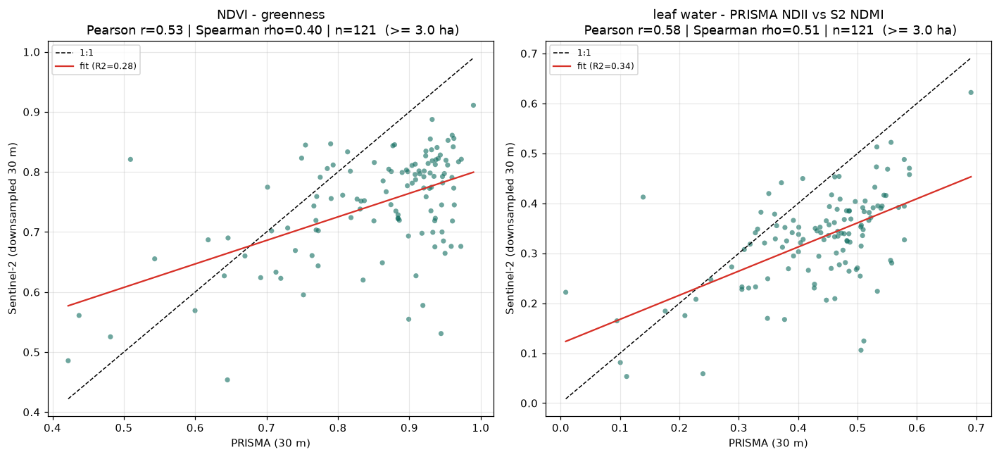

In [23]:
from scipy.stats import spearmanr
if val_ok and "NDVI_S2" in parcels:
    sel=parcels[parcels["area_ha"]>=VAL_MIN_HA]
    pairs=[("NDVI","NDVI_S2","NDVI - greenness"),
           ("NDII","NDMI_S2","leaf water - PRISMA NDII vs S2 NDMI")]
    fig,ax=plt.subplots(1,2,figsize=(13,6))
    for axi,(xp,yp,ttl) in zip(ax,pairs):
        d=sel[[xp,yp]].dropna()
        if len(d)>=3:
            x,y=d[xp].values,d[yp].values
            r=np.corrcoef(x,y)[0,1]; rho=spearmanr(x,y).correlation
            axi.scatter(x,y,s=22,color="#0E6B5E",alpha=.6,edgecolor="none")
            lim=[min(x.min(),y.min()),max(x.max(),y.max())]; axi.plot(lim,lim,"k--",lw=1,label="1:1")
            a,b=np.polyfit(x,y,1); xs=np.array(lim); axi.plot(xs,a*xs+b,color="#d73027",lw=1.5,label=f"fit (R2={r**2:.2f})")
            axi.set_title(f"{ttl}\n Pearson r={r:.2f} | Spearman rho={rho:.2f} | n={len(d)}  (>= {VAL_MIN_HA} ha)")
            axi.legend(fontsize=8)
        else:
            axi.text(.5,.5,"not enough parcels",ha="center",va="center",transform=axi.transAxes); axi.set_title(ttl)
        axi.set_xlabel("PRISMA (30 m)"); axi.set_ylabel("Sentinel-2 (downsampled 30 m)"); axi.grid(alpha=.3)
    plt.tight_layout(); plt.savefig("cross_sensor.png",dpi=130,bbox_inches="tight"); plt.show()
else:
    print("Cross-sensor skipped.")

🔎 Within-sensor (same image): MSI vs NDVI per parcel (PRISMA). Shows how moisture stress relates to greenness inside the hyperspectral image itself.

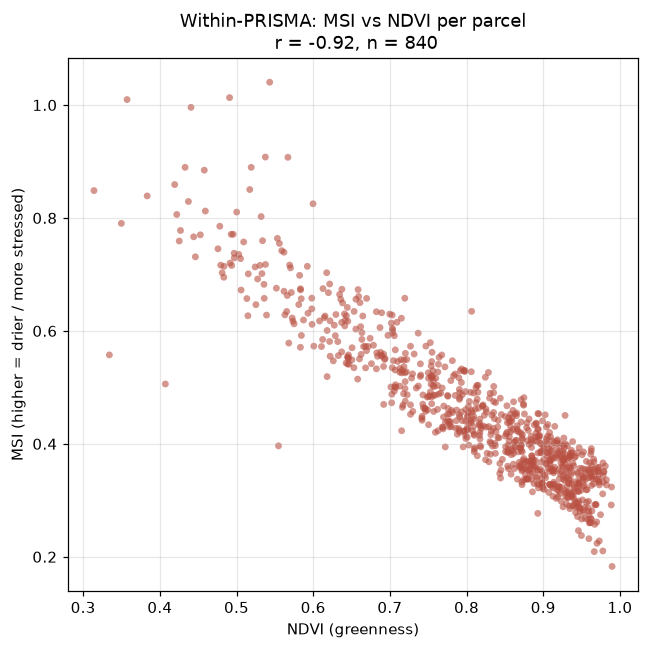

MSI vs NDVI (same sensor, PRISMA): r = -0.92


In [24]:
d=parcels[["NDVI","MSI"]].dropna()
if len(d)>=3:
    x,y=d["NDVI"].values,d["MSI"].values; r=np.corrcoef(x,y)[0,1]
    fig,ax=plt.subplots(figsize=(6,6))
    ax.scatter(x,y,s=20,color="#B85042",alpha=.6,edgecolor="none")
    ax.set_xlabel("NDVI (greenness)"); ax.set_ylabel("MSI (higher = drier / more stressed)")
    ax.set_title(f"Within-PRISMA: MSI vs NDVI per parcel\n r = {r:.2f}, n = {len(d)}")
    ax.grid(alpha=.3); plt.tight_layout(); plt.savefig("within_msi_ndvi.png",dpi=130,bbox_inches="tight"); plt.show()
    print(f"MSI vs NDVI (same sensor, PRISMA): r = {r:.2f}")
else:
    print("Not enough parcels for MSI vs NDVI.")

## 8. Sentinel-2 time series — full cycle (Nov -> Jun) + early-stress red-edge

Stressed vs healthy parcels over the season. 🟢 **NDVI** (greenness) and 💧 **NDMI** (moisture) are the usual signals; 🍂 **NDRE** (red-edge, S2 B8A/B05) is added as an **early-stress** indicator — the multi-date Sentinel-2 analogue of the single-date PRISMA **PRI** (section 3b): red-edge / PRI react **before** NDVI. The dashed line marks the PRISMA date.

Sentinel-2: 29 scenes over 2020-11-01 to 2021-06-30


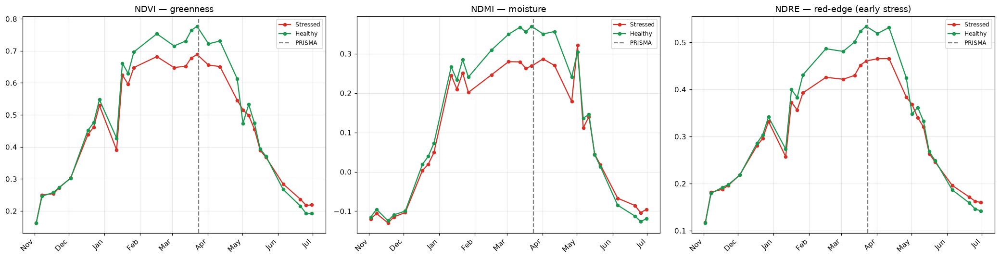

In [26]:
S2=None
try:
    import planetary_computer as pc, pystac_client
    from odc.stac import load as odc_load
    import rioxarray  # noqa
    bbox=transform_bounds(cube_crs,"EPSG:4326",*aoi_c.total_bounds)
    cat=pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1",modifier=pc.sign_inplace)
    items=list(cat.search(collections=["sentinel-2-l2a"],bbox=bbox,datetime=f"{TS_START}/{TS_END}",
                          query={"eo:cloud_cover":{"lt":40}}).items())
    ds=odc_load(items,bands=["B04","B05","B08","B8A","B11","SCL"],crs=cube_crs,resolution=20,bbox=bbox,chunks={},groupby="solar_day")
    ds=ds.where(~ds["SCL"].isin([0,1,3,8,9,10,11]))
    S2={"NDVI":((ds.B08-ds.B04)/(ds.B08+ds.B04)).rio.write_crs(cube_crs),
        "NDMI":((ds.B8A-ds.B11)/(ds.B8A+ds.B11)).rio.write_crs(cube_crs),
        "NDRE":((ds.B8A-ds.B05)/(ds.B8A+ds.B05)).rio.write_crs(cube_crs)}
    print(f"Sentinel-2: {len(items)} scenes over {TS_START} to {TS_END}")
except Exception as e:
    print("Time series unavailable:",e)

def fmt(ax):
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=10)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    for l in ax.get_xticklabels(): l.set_rotation(45); l.set_ha("right")
def gts(da,geoms):
    try:
        c=da.rio.clip(geoms,cube_crs,drop=True); return c.mean(dim=[d for d in c.dims if d!="time"]).to_series().dropna()
    except Exception: return None
if S2 is not None:
    st=parcels[parcels.severity.isin(["Severe","Moderate"])].geometry; he=parcels[parcels.severity=="Healthy"].geometry
    panels=[("NDVI","NDVI — greenness"),("NDMI","NDMI — moisture"),("NDRE","NDRE — red-edge (early stress)")]
    fig,ax=plt.subplots(1,3,figsize=(19,5))
    for axi,(k,ttl) in zip(ax,panels):
        for g,c,lab in [(st,"#d73027","Stressed"),(he,"#1a9850","Healthy")]:
            if len(g):
                s=gts(S2[k],g)
                if s is not None and len(s): axi.plot(s.index,s.values,"o-",color=c,label=lab,ms=4)
        axi.axvline(np.datetime64(PRISMA_DATE),ls="--",color="gray",label="PRISMA"); axi.set_title(ttl); axi.legend(fontsize=8); axi.grid(alpha=.3); fmt(axi)
    plt.tight_layout(); plt.savefig("timeseries_cycle.png",dpi=130,bbox_inches="tight"); plt.show()

## 8b. Per-parcel deep-dive — signature · water vs NDVI · time series (interactive)

For any parcel: its **mean spectral signature** 📈; a **pixel-level scatter of a water index (NDWI) against NDVI** inside the parcel — greenness vs leaf-water content — with a regression fit, *r*, and a **colour bar encoding MSI** (moisture-stress index: higher = drier) to read each pixel; and its **Sentinel-2 time series** over the cycle. This is a *descriptive* view of the parcel's internal variability (not the cross-sensor validation, which stays in section 7).

Parcel 0  |  Healthy  |  {'NDVI': 0.965, 'SAVI': 0.855, 'NDRE': 0.317, 'REP': 721.604, 'NDWI': 0.216, 'NDII': 0.505, 'MSI': 0.329, 'NDNI': 0.178, 'NDTI': 0.375, 'PRI': -0.218, 'WBI': 1.179, 'CRD970': 0.216, 'CRD1200': 0.138, 'REIP': 723.88}


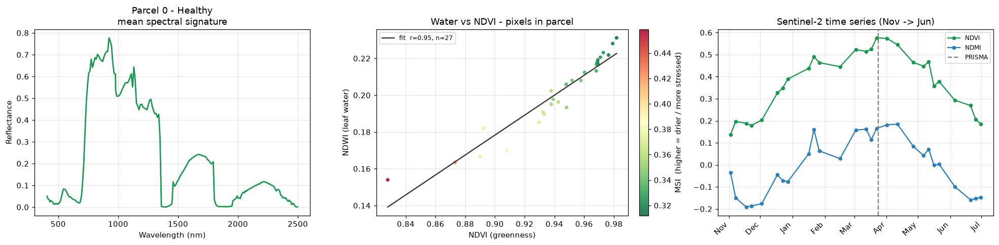

In [27]:
# per-parcel deep dive: signature | water index vs NDVI (colour = MSI) | Sentinel-2 time series
def parcel_mask(pid):
    row=parcels[parcels.pid==pid]
    if row.empty: return None,None
    m=geometry_mask([row.geometry.values[0]],out_shape=(cube.shape[1],cube.shape[2]),transform=cube_tr,invert=True)
    return row,m

def analyse_parcel(pid):
    row,m=parcel_mask(pid)
    if row is None: print("pid",pid,"not found"); return
    sev=row["severity"].values[0]
    fig,ax=plt.subplots(1,3,figsize=(18,4.5))

    # (1) mean spectral signature
    sig=np.nanmean(cube[:,m],axis=1)
    ax[0].plot(wl,sig,color="#1a9850",lw=1.8)
    ax[0].set_xlabel("Wavelength (nm)"); ax[0].set_ylabel("Reflectance")
    ax[0].set_title(f"Parcel {pid} - {sev}\nmean spectral signature"); ax[0].grid(alpha=.3)

    # (2) water (NDWI) vs greenness (NDVI) for the pixels inside the parcel; colour = MSI (stress)
    xv=NDVI[m].ravel(); yv=NDWI[m].ravel(); cv=MSI[m].ravel()
    ok=np.isfinite(xv)&np.isfinite(yv); xv,yv,cvv=xv[ok],yv[ok],cv[ok]
    if len(xv)>=3:
        sc=ax[1].scatter(xv,yv,c=cvv,s=22,cmap="RdYlGn_r",alpha=.85,edgecolor="none")
        cb=fig.colorbar(sc,ax=ax[1],fraction=.046,pad=.04); cb.set_label("MSI  (higher = drier / more stressed)")
        a,b=np.polyfit(xv,yv,1); r=np.corrcoef(xv,yv)[0,1]
        xs=np.array([xv.min(),xv.max()])
        ax[1].plot(xs,a*xs+b,color="#333",lw=1.5,label=f"fit  r={r:.2f}, n={len(xv)}")
        ax[1].legend(fontsize=8,loc="best")
    else:
        ax[1].text(.5,.5,"not enough pixels\n(parcel too small at 30 m)",ha="center",va="center",transform=ax[1].transAxes)
    ax[1].set_xlabel("NDVI (greenness)"); ax[1].set_ylabel("NDWI (leaf water)")
    ax[1].set_title("Water vs NDVI - pixels in parcel"); ax[1].grid(alpha=.3)

    # (3) Sentinel-2 time series over the cycle for this parcel
    if S2 is not None:
        g=[row.geometry.values[0]]
        for da,c,lab in [(S2["NDVI"],"#1a9850","NDVI"),(S2["NDMI"],"#2c7fb8","NDMI")]:
            s=gts(da,g)
            if s is not None and len(s): ax[2].plot(s.index,s.values,"o-",color=c,label=lab,ms=4)
        ax[2].axvline(np.datetime64(PRISMA_DATE),ls="--",color="gray",label="PRISMA"); ax[2].legend(fontsize=8); fmt(ax[2])
    else:
        ax[2].text(.5,.5,"time series unavailable",ha="center",va="center",transform=ax[2].transAxes)
    ax[2].set_title("Sentinel-2 time series (Nov -> Jun)"); ax[2].grid(alpha=.3)

    vals={n:round(float(row[n].values[0]),3) for n in indices if n in row.columns and pd.notna(row[n].values[0])}
    print(f"Parcel {pid}  |  {sev}  |  {vals}")
    plt.tight_layout(); plt.show()

# default example: first parcel with a valid (vegetated) NDVI, so the demo is meaningful
_veg=parcels[parcels["NDVI"].notna()]
analyse_parcel(int(_veg.pid.iloc[0] if len(_veg) else parcels.pid.iloc[0]))

**Interactive selector — pick any parcel from the dropdown and its triptych redraws below.**

### 🎛️ Interactive parcel selector

Pick any parcel from the **dropdown** and its deep-dive triptych (signature · NDWI-vs-NDVI · time series) redraws just below. 🔄

> ℹ️ **If the view doesn't refresh when you change the selection, simply re-run this cell** — the live update relies on an `ipywidgets` callback that needs an active kernel (it won't fire after a kernel restart, and the widget is static on GitHub/nbviewer). You can also call `analyse_parcel(<pid>)` directly for any parcel id. ✅

In [28]:
try:
    import ipywidgets as widgets
    from IPython.display import display
    order={s:i for i,s in enumerate(SEV_ORDER)}
    pp=parcels.sort_values("severity",key=lambda c:c.map(order))
    opts=[(f"{int(p)} — {s}", int(p)) for p,s in zip(pp.pid, pp.severity)]
    dd=widgets.Dropdown(options=opts, description="Parcel:")
    out=widgets.Output()
    def _on(change):
        if change["name"]=="value":
            with out: out.clear_output(wait=True); analyse_parcel(change["new"])
    dd.observe(_on)
    display(dd, out)
    with out: analyse_parcel(dd.value)
except Exception as e:
    print("ipywidgets selector unavailable — call analyse_parcel(pid) directly. (",e,")")

Dropdown(description='Parcel:', options=(('12 — Healthy', 12), ('11 — Healthy', 11), ('10 — Healthy', 10), ('8…

Output()

**Interactive map — click a parcel to read its ID, severity and index values. Saved as a standalone HTML.**

In [29]:
import folium, branca
os.makedirs("outputs",exist_ok=True)
gj=parcels.to_crs(4326).copy()
show_cols=[n for n in indices if n in gj]+(["NDVI_S2"] if "NDVI_S2" in gj else [])
for n in show_cols: gj[n]=gj[n].astype(float).round(3)
gj["area_ha"]=gj["area_ha"].round(2)
gj["stress_pct"]=gj["stress_pct"].astype(float).round(1)
gj["priority"]=gj["priority"].astype(float)
uni=gj.geometry.union_all() if hasattr(gj.geometry,"union_all") else gj.geometry.unary_union
c=uni.centroid
fmap=folium.Map(location=[c.y,c.x], zoom_start=14, tiles="CartoDB positron")

# colour parcels by the composite stress % (higher = priority); grey = non-vegetated
cmap=branca.colormap.LinearColormap(["#1a9850","#fee08b","#fc8d59","#d73027"],vmin=0,vmax=100,
     caption="Composite water-stress (%) - higher = priority")
def _style(feat):
    v=feat["properties"].get("stress_pct")
    fc=cmap(v) if (v is not None and v==v) else "#9e9e9e"
    return {"fillColor":fc,"color":"white","weight":0.4,"fillOpacity":0.82}

fields=["pid","stress_pct","priority","severity","area_ha"]+show_cols
folium.GeoJson(gj[["geometry"]+fields], style_function=_style,
               highlight_function=lambda f:{"weight":2,"color":"#333"},
               tooltip=folium.GeoJsonTooltip(fields=["pid","stress_pct","severity"],
                                             aliases=["Parcel","Stress %","Class"]),
               popup=folium.GeoJsonPopup(fields=fields)).add_to(fmap)
cmap.add_to(fmap)
fmap.save("outputs/HyWAP_interactive_map.html")
print("Interactive map saved: outputs/HyWAP_interactive_map.html  (coloured by stress %)")
fmap

Interactive map saved: outputs/HyWAP_interactive_map.html  (coloured by stress %)


## 9. Export results

In [30]:
os.makedirs("outputs",exist_ok=True)
names=list(indices.keys())
prof={"driver":"GTiff","height":cube.shape[1],"width":cube.shape[2],"count":len(names),
      "dtype":"float32","crs":cube_crs,"transform":cube_tr,"nodata":np.nan}
with rasterio.open("outputs/indices_stack.tif","w",**prof) as dst:
    for i,n in enumerate(names,1): dst.write(indices[n].astype("float32"),i); dst.set_band_description(i,n)
parcels.to_file("outputs/parcels_severity.gpkg",driver="GPKG")
parcels.drop(columns="geometry").to_csv("outputs/parcels_table.csv",index=False)
print("Saved: outputs/indices_stack.tif, parcels_severity.gpkg, parcels_table.csv, PRISMA_pansharp.tif")

Saved: outputs/indices_stack.tif, parcels_severity.gpkg, parcels_table.csv, PRISMA_pansharp.tif


---
### 📝 Notes
- **Delineation** = AgriBound **merged with segmentation** (removes roads / non-field), then **Douglas-Peucker** boundary simplification. The NDVI road mask was dropped (no added value once AgriBound is used).
- **Outputs**: the delineation GeoPackage (`parcels_delineation.gpkg`), the study-area boundary GeoPackage (`study_area_boundary.gpkg`), the per-parcel severity GeoPackage, the index stack, the per-parcel table and the interactive map. 🗂️
- **Validation** is **cross-sensor** (PRISMA vs Sentinel-2, per parcel), tightened by time window and parcel size.
- **Time series** covers the **full cycle (Nov → Jun)**.
- ℹ️ Severity is **relative to the scene** — description, not forecasting. **PRISMA** (400–2500 nm, 30 m) is the **open analogue of 813**.

---
_Made with 💚 by Team CRTS — Royal Center for Remote Sensing, Rabat, Morocco._